# Mini Projeto: Classificação de Peças com OpenCV e CNN
**Curso SC TEC - Módulo 2**

Este notebook abrange a construção de um pipeline completo de Visão Computacional e Deep Learning para inspeção de qualidade industrial. O objetivo é classificar imagens de peças fundidas (*casting*) entre **sem defeito** (`ok_front`) e **com defeito** (`def_front`).

---
## 1. Configuração do Ambiente e Ingestão do Dataset

Nesta etapa, realizamos o download e a extração automatizada do conjunto de dados `casting_512x512` a partir do repositório do projeto. É feita a verificação da estrutura de diretórios para garantir que todas as imagens estejam disponíveis nos caminhos esperados.

# Importação do Dataset

Ha métodos diferentes para importar o dataset, se estiver rodando VS Code, ou Colab. Rode a célula abaixo de acordo com o que você estiver usando.

## Colab (via URL)

In [1]:
print("\n-> 1. Baixando e Extraindo o Dataset")

# Limpeza Previa
!rm -f casting_512x512.zip

# Baixa o dataset usando a URL de download direto correta
!wget -q --show-progress -O casting_512x512.zip https://github.com/dnkamo/SC_TEC-M2_S07-Mini-Projeto-CNN-OpenCV-Pecas/raw/main/dataset/casting_512x512.zip

# Extrai o conteúdo
!unzip -q -o casting_512x512.zip
print("Download e extração concluídos!")


-> 1. Baixando e Extraindo o Dataset
casting_512x512.zip 100%[===================>]  30.69M   135MB/s    in 0.2s    
Download e extração concluídos!


## Arquivo Local

In [ ]:
print("\n-> 1. Extraindo o Dataset Localmente")

import os
import zipfile

# Definindo os caminhos corretos
nome_zip = "../dataset/casting_512x512.zip"
pasta_extraida = "casting_512x512"

# Verificando se o arquivo zip existe antes de tentar extrair
if os.path.exists(nome_zip):

    if not os.path.exists(pasta_extraida):

        print("Extraindo as imagens...")
        with zipfile.ZipFile(nome_zip, 'r') as zip_ref:

            zip_ref.extractall(pasta_extraida)

        print("Extração concluída!")
    else:
        print("O Dataset já está extraído!")
else:
    print(f"ERRO: O arquivo '{nome_zip}' não foi encontrado para extração.")

## Teste de Verificação

In [2]:
# ========================================================
# Verificando se o dataset está extraído e pronto para usar

import os

nome_zip = "casting_512x512.zip"
pasta_extraida = 'casting_512x512'

if os.path.exists(pasta_extraida):
    print(f"Verificando a pasta: {pasta_extraida}")
    for root, dirs, files in os.walk(pasta_extraida):
        level = root.replace(pasta_extraida, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f"{indent}{os.path.basename(root)}/ - {len(files)} arquivos")
else:
    print(f"ERRO: A pasta '{pasta_extraida}' não foi encontrada. Verifique se a extração ocorreu corretamente.")

Verificando a pasta: casting_512x512
casting_512x512/ - 0 arquivos
    ok_front/ - 519 arquivos
    def_front/ - 781 arquivos


## 1.1 Análise Exploratória de Dados (EDA) e Balanceamento de Classes

Antes do modelamento, analisamos a proporção entre as classes `ok_front` e `def_front`. Identificar a distribuição das imagens é fundamental para escolher as métricas adequadas de avaliação e ajustar a estratégia de treinamento da rede neural.

Classes encontradas: ['def_front', 'ok_front']
Distribuição no Treino (Total do Dataset): {'def_front': 781, 'ok_front': 519}


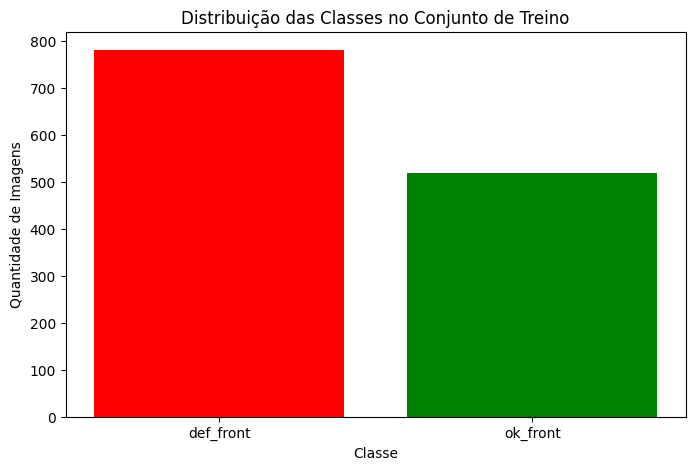

In [3]:
# ======================================================
# 1.1 EDA: BALANCEAMENTO DE CLASSES
# ======================================================

import matplotlib.pyplot as plt
import os

# Definindo os caminhos das pastas das classes
dir_ok = 'casting_512x512/ok_front'
dir_def = 'casting_512x512/def_front'

# Nomes das classes
nomes_classes = ['def_front', 'ok_front']

# Contando a quantidade de imagens em cada diretório de forma robusta
qtd_def = len(os.listdir(dir_def)) if os.path.exists(dir_def) else 0
qtd_ok = len(os.listdir(dir_ok)) if os.path.exists(dir_ok) else 0

# Criando o dicionário correspondente para simular o comportamento anterior
# 'def_front' mapeado para 0 e 'ok_front' mapeado para 1
counts_dict = {0: qtd_def, 1: qtd_ok}

print(f"Classes encontradas: {nomes_classes}")
print(f"Distribuição no Treino (Total do Dataset): {{'def_front': {qtd_def}, 'ok_front': {qtd_ok}}}")

# Plotagem
plt.figure(figsize=(8, 5))
plt.bar(nomes_classes, [qtd_def, qtd_ok], color=['red', 'green'])
plt.title('Distribuição das Classes no Conjunto de Treino')
plt.xlabel('Classe')
plt.ylabel('Quantidade de Imagens')
plt.show()

A partir dessa saída, podemos tirar algumas conclusões:

1. O dataset possuí **duas** classes:

    *   `ok_front`: Peças sem defeitos.
    *   `def_front`: Peças com defeitos.

2. A quantidade de imagens para cada classe:

    *   A classe `ok_front` tem `519` (**39.9%**) imagens.
    *   A classe `def_front` tem `781` (**60.1%**) imagens.
    *   O dataset em total possuí `1300` imagens.

Podemos ver que o dataset possuí um leve desbalanceamento, portanto, será necessário manter isso em mente durante a fase de treinamento do modelo.

# 2. Analise Exploratória com OpenCV

Vamos iniciar validando a importação do dataset por meio da amostragem e visualização de algumas imagens.

Começamos importando as bibliotecas de Visão Computacional `cv2` (**OpenCV**) para visualizar e aplicar filtros nas imagens, junto com a biblioteca `os` para achar o caminho da pasta da imagem.

-> 2. Mostrando imagens de amostra


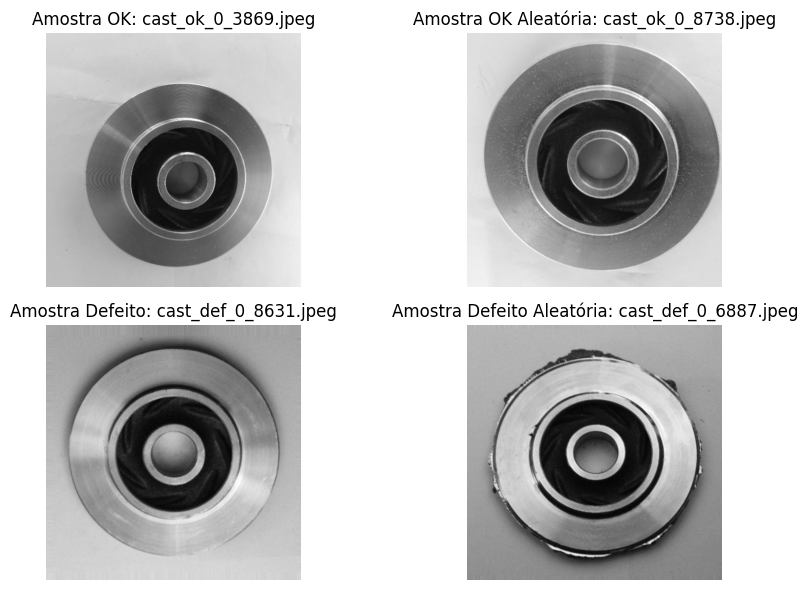

In [4]:
# =====================================
# 1. PEGANDO IMAGENS DE AMOSTRA
# =====================================

import cv2
import matplotlib.pyplot as plt
import os
import random

# Caminhos das pastas
dir_ok = 'casting_512x512/ok_front'
dir_def = 'casting_512x512/def_front'

# Para deixar as imagens consistentes, podemos pegar as primeiras
# imagens de cada pasta, ou podemos pegar uma imagem qualquer
# por meio de escolha aleatória

# METODO 1
# Pegando as primeiras imagens:
# ------------------------------------

# Listando os arquivos (pegando os primeiros 1 de cada)
img_ok_name = os.listdir(dir_ok)[0]
img_def_name = os.listdir(dir_def)[0]

# METODO 2
# Pegando imagens aleatórias:
# ------------------------------------

img_ok_name_random = os.listdir(dir_ok)
img_def_name_random = os.listdir(dir_def)

img_ok_choice_random = random.choice(img_ok_name_random)
img_def_choice_random = random.choice(img_def_name_random)

# Lendo as imagens com OpenCV
# ------------------------------------
# Primeiras
img_ok = cv2.imread(os.path.join(dir_ok, img_ok_name))
img_def = cv2.imread(os.path.join(dir_def, img_def_name))

# Aleatório
img_ok_random = cv2.imread(os.path.join(dir_ok, img_ok_choice_random))
img_def_random = cv2.imread(os.path.join(dir_def, img_def_choice_random))

# OBS: O OpenCV lê imagens no formato BGR, portanto, precisamos
# converter para RGB

# ------------------------------------
# Convertendo de BGR (OpenCV) para RGB (Matplotlib)
img_ok_rgb = cv2.cvtColor(img_ok, cv2.COLOR_BGR2RGB)
img_def_rgb = cv2.cvtColor(img_def, cv2.COLOR_BGR2RGB)

img_ok_rgb_random = cv2.cvtColor(img_ok_random, cv2.COLOR_BGR2RGB)
img_def_rgb_random = cv2.cvtColor(img_def_random, cv2.COLOR_BGR2RGB)

print("="*40)
print("-> 2. Mostrando imagens de amostra")
print("="*40)

# Exibindo as amostras
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes[0, 0].imshow(img_ok_rgb)
axes[0, 0].set_title(f'Amostra OK: {img_ok_name}')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_ok_rgb_random)
axes[0, 1].set_title(f'Amostra OK Aleatória: {img_ok_choice_random}')
axes[0, 1].axis('off')

axes[1, 0].imshow(img_def_rgb)
axes[1, 0].set_title(f'Amostra Defeito: {img_def_name}')
axes[1, 0].axis('off')

axes[1, 1].imshow(img_def_rgb_random)
axes[1, 1].set_title(f'Amostra Defeito Aleatória: {img_def_choice_random}')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

Pegamos não apenas a primeira imagem de cada pasta, assim como uma imagem aleatória de cada classe, para visualizar a diferença entre as imagens do dataset.

## 2.1 Processamento e Destaque de Características com OpenCV

Utilizamos a biblioteca OpenCV para aplicar técnicas clássicas de Visão Computacional nas amostras:
- **Escala de Cinza e Desfoque (GaussianBlur):** Redução de ruído e suavização das matrizes de pixel.
- **Detecção de Bordas (Canny):** Destaque dos contornos, trincas e imperfeições.
- **Limiarização Binária (Thresholding) e Morfologia (`Closing`):** Isola o objeto e preenche falhas internas na máscara visual.
- **Controles Interativos (`ipywidgets`):** Permite o ajuste fino dos limiares de detecção em tempo real.

-> 3. Aplicando filtros e convertendo em escala de cinza...



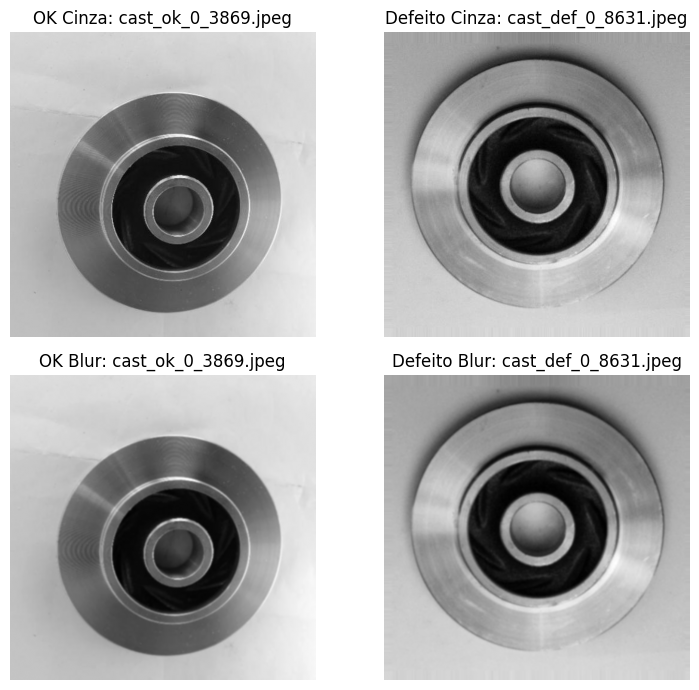

In [5]:
# ======================================================
# 2. APLICANDO FILTROS NAS IMAGENS
# ======================================================

# Com nossas amostras selecionadas, podemos aplicar
# conversão em escala de cinza, assim como filtros
# de suavização

print("="*40)
print("-> 3. Aplicando filtros e convertendo em escala de cinza...")
print("="*40)
print()

# ====
# A. Conversão para escala de cinza
# ---------------------------------
img_ok_cinza = cv2.cvtColor(img_ok_rgb, cv2.COLOR_RGB2GRAY)
img_def_cinza = cv2.cvtColor(img_def_rgb, cv2.COLOR_RGB2GRAY)

# ====
# B. Gaussian Blur ou Median Blur, para suavizar os detalhes
# ---------------------------------
# Variavel para usar no tamanho dos desfoque varias vezes de uma so vez
tamanho_desfoque = (5, 5)

img_ok_cinza_blur = cv2.GaussianBlur(img_ok_cinza, tamanho_desfoque, 0)
img_def_cinza_blur = cv2.GaussianBlur(img_def_cinza, tamanho_desfoque, 0)

#img_ok_cinza_blur = cv2.medianBlur(img_ok_cinza, tamanho_desfoque[0])
#img_def_cinza_blur = cv2.medianBlur(img_def_cinza, tamanho_desfoque[0])


# ====
# ---------------------------------
# Mostrando as imagens processadas até agora

fig, axes = plt.subplots(2, 2, figsize=(8, 7))

# Exibindo imagens em escala de cinza
axes[0, 0].imshow(img_ok_cinza, cmap='gray')
axes[0, 0].set_title(f'OK Cinza: {img_ok_name}')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_def_cinza, cmap='gray')
axes[0, 1].set_title(f'Defeito Cinza: {img_def_name}')
axes[0, 1].axis('off')

# Exibindo imagens com Blur
axes[1, 0].imshow(img_ok_cinza_blur, cmap='gray')
axes[1, 0].set_title(f'OK Blur: {img_ok_name}')
axes[1, 0].axis('off')

axes[1, 1].imshow(img_def_cinza_blur, cmap='gray')
axes[1, 1].set_title(f'Defeito Blur: {img_def_name}')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

### **Análise dos Resultados**

Vamos analisar o que está sendo feito até aqui, e o que podemos concluir ao ver a saída das celulas:

1. **Amostragem de Imagens e Conversão de Cores:**
   * **Espaço de Cores:** O OpenCV carrega nativamente as imagens no padrão BGR. A conversão para RGB via `cv2.cvtColor(..., cv2.COLOR_BGR2RGB)` foi indispensável para garantir que as cores reais fossem exibidas corretamente pelo Matplotlib.
   * **Inspeção Visual Inicial:** Ao comparar as amostras da classe `ok_front` (peças perfeitas) com a classe `def_front` (peças com defeito), observa-se que as falhas industriais se manifestam na forma de trincas, orifícios não preenchidos ou deformações na estrutura metálica central e nas bordas da peça.

2. **Conversão para Escala de Cinza e Desfoque Gaussiano:**
   * **Escala de Cinza:** Reduz a complexidade da imagem de 3 canais (RGB) para apenas 1 canal de intensidade luminosa. Isso otimiza o processamento e foca a análise na variação de brilho e textura.
   * **Desfoque Gaussiano (`GaussianBlur` kernel 5x5):** A aplicação do desfoque atua como um filtro passa-baixas, reduzindo o ruído de alta frequência (pequenas imperfeições irrelevantes na rugosidade da peça) sem eliminar o contorno principal dos defeitos estruturais. Esse pré-processamento garante maior estabilidade para as etapas de detecção de bordas e limiarização.

# 3. Destaque de Características (Limiarização e Bordas)

-> 4. Aplicando filtros OpenCV (Bordas, Limiarização e Morfologia)

Processamento concluído!
Mostrando os resultados dos filtros:



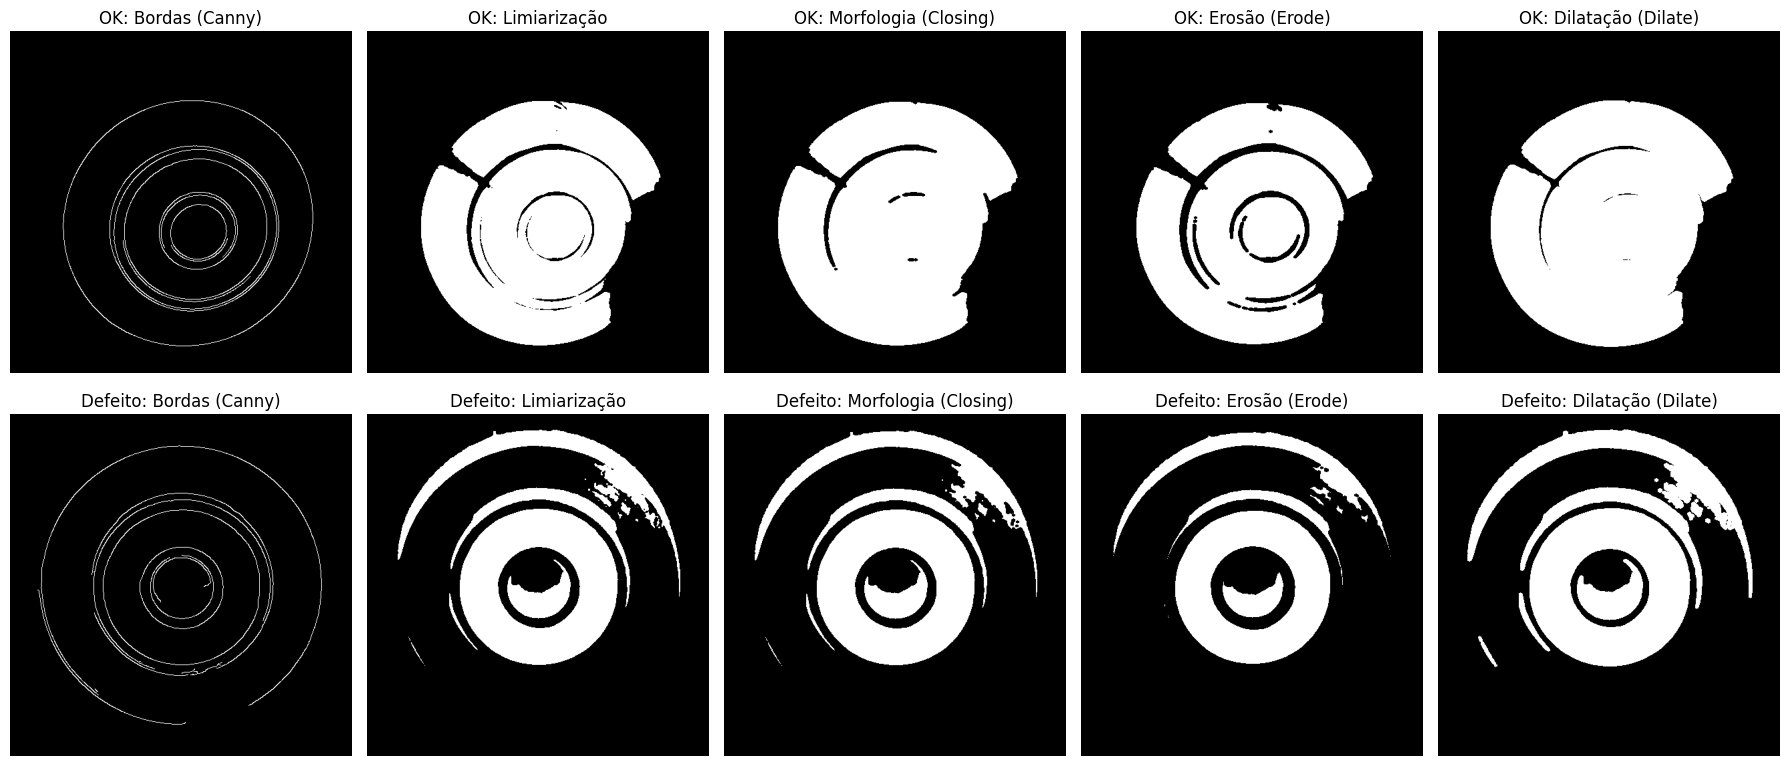

In [9]:
# ======================================================
# 3. DESTAQUE DE DETALHES (BORDAS) E LIMIARIZAÇÃO
# ======================================================

print("="*40)
print("-> 4. Aplicando filtros OpenCV (Bordas, Limiarização e Morfologia)")
print("="*40)
print()

# Definição de hiperparâmetros para facilitar o ajuste
canny_min = 40
canny_max = 215
limiar_valor = 121

# ====
# A. Detecção de Bordas
# ---------------------------------

img_ok_bordas = cv2.Canny(img_ok_cinza_blur, canny_min, canny_max)
img_def_bordas = cv2.Canny(img_def_cinza_blur, canny_min, canny_max)

# ====
# B. Limiarização Binaria (Threshold)
# ---------------------------------

_, img_ok_limiar = cv2.threshold(img_ok_cinza_blur, limiar_valor, 255, cv2.THRESH_BINARY_INV)
_, img_def_limiar = cv2.threshold(img_def_cinza_blur, limiar_valor, 255, cv2.THRESH_BINARY_INV)

# ====
# C. Operações Morfológicas (Fechamento, Erosão e Dilatação)
# ---------------------------------

# Definindo o kernel (matriz de estruturação)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

# Aplicando o fechamento (Closing) para preencher buracos internos
img_ok_morph = cv2.morphologyEx(img_ok_limiar, cv2.MORPH_CLOSE, kernel)
img_def_morph = cv2.morphologyEx(img_def_limiar, cv2.MORPH_CLOSE, kernel)

# Exemplo de Erosão (cv2.erode) - Encolhe as áreas brancas, removendo ruídos pequenos
img_ok_erode = cv2.erode(img_ok_limiar, kernel, iterations=1)
img_def_erode = cv2.erode(img_def_limiar, kernel, iterations=1)

# Exemplo de Dilatação (cv2.dilate) - Expande as áreas brancas, preenchendo falhas
img_ok_dilate = cv2.dilate(img_ok_limiar, kernel, iterations=1)
img_def_dilate = cv2.dilate(img_def_limiar, kernel, iterations=1)

print("Processamento concluído!")
print("Mostrando os resultados dos filtros:\n")

# Exibindo os resultados das etapas de destaque
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

# Coluna 1: Bordas (Canny)
axes[0, 0].imshow(img_ok_bordas, cmap='gray')
axes[0, 0].set_title('OK: Bordas (Canny)')
axes[1, 0].imshow(img_def_bordas, cmap='gray')
axes[1, 0].set_title('Defeito: Bordas (Canny)')

# Coluna 2: Limiarização (Threshold)
axes[0, 1].imshow(img_ok_limiar, cmap='gray')
axes[0, 1].set_title('OK: Limiarização')
axes[1, 1].imshow(img_def_limiar, cmap='gray')
axes[1, 1].set_title('Defeito: Limiarização')

# Coluna 3: Morfologia (Closing)
axes[0, 2].imshow(img_ok_morph, cmap='gray')
axes[0, 2].set_title('OK: Morfologia (Closing)')
axes[1, 2].imshow(img_def_morph, cmap='gray')
axes[1, 2].set_title('Defeito: Morfologia (Closing)')

# Coluna 4: Erosão
axes[0, 3].imshow(img_ok_erode, cmap='gray')
axes[0, 3].set_title('OK: Erosão (Erode)')
axes[1, 3].imshow(img_def_erode, cmap='gray')
axes[1, 3].set_title('Defeito: Erosão (Erode)')

# Coluna 5: Dilatação
axes[0, 4].imshow(img_ok_dilate, cmap='gray')
axes[0, 4].set_title('OK: Dilatação (Dilate)')
axes[1, 4].imshow(img_def_dilate, cmap='gray')
axes[1, 4].set_title('Defeito: Dilatação (Dilate)')

for ax in axes.flatten():
    ax.axis('off')

plt.tight_layout()
plt.show()

Utilizamos os filtros a seguir, cada um com sua função específica:

1. **Filtro de Bordas Canny (`cv2.Canny`):**
   * O algoritmo Canny destaca com precisão os contornos geométricos da peça. Nas peças defeituosas (`def_front`), ele evidencia nitidamente as descontinuidades causadas por trincas e rachaduras internas, que aparecem como linhas adicionais no interior do contorno principal.

2. **Limiarização Binária Invertida (`cv2.threshold` com `THRESH_BINARY_INV`):**
   * Utilizando o valor de limiar de `121`, o algoritmo separa o objeto (peça metálica) do fundo com base na intensidade de cinza. A inversão garante que a peça e suas ranhuras fiquem em evidência na máscara binária (pixels brancos sobre fundo preto).

3. **Operação Morfológica de Fechamento (`cv2.MORPH_CLOSE`):**
   * Com o uso de um kernel elíptico $5 \times 5$, a operação morfológica de fechamento realiza a dilatação seguida de erosão. Isso auxilia na união de contornos desconectados e no preenchimento de pequenos buracos e ruídos internos dentro da região limiarizada.

4. **Operação Morfológica de Erosão (`cv2.erode`):**
   * Utiliza o kernel para "encolher" as áreas brancas na máscara binária. É extremamente útil para eliminar pequenos ruídos isolados (falsos positivos) e desconectar elementos finos indesejados.

5. **Operação Morfológica de Dilatação (`cv2.dilate`):**
   * Ao contrário da erosão, a dilatação "expande" as áreas brancas. É ideal para preencher pequenos buracos e emendar quebras em contornos que deveriam ser contínuos.

### **Criação de filtros interativos**

Para facilitar o processo de achar o melhor valor que abrange o maior número de imagens possível, vamos criar uma versão interativa dos filtros para mudar os valores e atualizar as imagens com os filtros aplicados instantaneamente.

In [10]:
import ipywidgets as widgets
from ipywidgets import interact

# Filtros interativos para descobrir o melhor valor para detectar bordas

def update_filters(c_min, c_max, thresh):
    # Re-aplicando Canny com novos valores
    ok_edges = cv2.Canny(img_ok_cinza_blur, c_min, c_max)
    def_edges = cv2.Canny(img_def_cinza_blur, c_min, c_max)

    # Re-aplicando Threshold com novo valor
    _, ok_thresh = cv2.threshold(img_ok_cinza_blur, thresh, 255, cv2.THRESH_BINARY_INV)
    _, def_thresh = cv2.threshold(img_def_cinza_blur, thresh, 255, cv2.THRESH_BINARY_INV)

    # Plotagem
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes[0, 0].imshow(ok_edges, cmap='gray')
    axes[0, 0].set_title(f'OK: Canny ({c_min}, {c_max})')
    axes[0, 1].imshow(ok_thresh, cmap='gray')
    axes[0, 1].set_title(f'OK: Threshold ({thresh})')

    axes[1, 0].imshow(def_edges, cmap='gray')
    axes[1, 0].set_title(f'Defeito: Canny ({c_min}, {c_max})')
    axes[1, 1].imshow(def_thresh, cmap='gray')
    axes[1, 1].set_title(f'Defeito: Threshold ({thresh})')

    for ax in axes.flatten():
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Criando os controles interativos
interact(update_filters,
         c_min=widgets.IntSlider(min=0, max=255, step=1, value=40, description='Canny Min'),
         c_max=widgets.IntSlider(min=0, max=255, step=1, value=215, description='Canny Max'),
         thresh=widgets.IntSlider(min=0, max=255, step=1, value=125, description='Limiar'))

interactive(children=(IntSlider(value=40, description='Canny Min', max=255), IntSlider(value=215, description=…

<function __main__.update_filters(c_min, c_max, thresh)>

**Ajuste Interativo de Hiperparâmetros:**
   * Os *widgets* interativos permitem simular em tempo real a sensibilidade dos limiares de Canny (`c_min`, `c_max`) e Threshold (`thresh`). Esse processo experimental é essencial para definir os limites ideais de segmentação que melhor isolam os defeitos antes da alimentação na rede neural.

# 4. Ingestão de Dados, Divisão Estratificada e Data Augmentation

Para garantir um processo rigoroso de validação:
1. **Divisão dos Dados:** Divisão proporcional em **Treino (70%)**, **Validação (15%)** e **Teste Cego (15%)**.
2. **Otimização de Desempenho:** Uso de `cache()` e `prefetch()` com `tf.data.AUTOTUNE` para otimizar a leitura e processamento na GPU.
3. **Data Augmentation:** Introdução de rotações, espelhamentos, zoom e variações de brilho/contraste no treino para aumentar a robustez e mitigar o *overfitting*.

In [ ]:
# ======================================================
# 4. DIVISÃO DE TREINO E VALIDAÇÃO (KERAS) OTIMIZADA
# ======================================================

import tensorflow as tf
import pathlib
import os

# O Dataset já foi importado e verificado anteriormente para
# processar as imagens com OpenCV, portanto não iremos baixar
# ou verificar novamente

print("="*40)
print("-> 5. Separando em Treino, Validação e Teste:")
print("="*40)
print()

# Definindo o caminho para a pasta
pasta_extraida = "casting_512x512"
pasta_raiz = pathlib.Path(pasta_extraida)

altura_img, largura_img = 512, 512
tamanho_lote = 32

# ====
# A. Separando os dados para treino
dados_treino = tf.keras.utils.image_dataset_from_directory(
    pasta_raiz,
    color_mode='grayscale', # Converte o RGB para Escala de Cinza
    validation_split=0.3,
    subset="training",      # Pega a maior parte da divisão
    seed=42,
    image_size=(altura_img, largura_img),
    batch_size=tamanho_lote
)

# ====
# B. Separando os dados para validação
dados_validacao = tf.keras.utils.image_dataset_from_directory(
    pasta_raiz,
    color_mode='grayscale',
    validation_split=0.3,
    subset="validation",  # Mudou para carregar os 30% de teste
    seed=42,              # A semente precisa ser igual
    image_size=(altura_img, largura_img),
    batch_size=tamanho_lote
)

# ====
# C. Divindo os dados de validação em dois (Validação e Teste)

nomes_classes = dados_treino.class_names

# Calcula os lotes (batches) que existem na reserva
total_lotes_reserva = tf.data.experimental.cardinality(dados_validacao).numpy()

# Dividindo pela metade (15% pro Simulado, 15% pra Prova Final)
lotes_val = total_lotes_reserva // 2

# Pega a primeira metade para Validação
dados_val = dados_validacao.take(lotes_val)

# Guarda a segunda para Teste Final
dados_teste = dados_validacao.skip(lotes_val)

# ====
# D. OTIMIZAÇÃO DE PERFORMANCE (tf.data.AUTOTUNE)
# O cache() guarda os dados na memória e o prefetch() prepara lotes em paralelo

AUTOTUNE = tf.data.AUTOTUNE

dados_treino = dados_treino.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
dados_val = dados_val.cache().prefetch(buffer_size=AUTOTUNE)
dados_teste = dados_teste.cache().prefetch(buffer_size=AUTOTUNE)

print(f"\nDivisão Finalizada!")
print(f"Classes: {nomes_classes}")
print(f"Lotes para Treino: {tf.data.experimental.cardinality(dados_treino).numpy()}")
print(f"Lotes para Validação: {tf.data.experimental.cardinality(dados_val).numpy()}")
print(f"Lotes para Teste Cego: {tf.data.experimental.cardinality(dados_teste).numpy()}")

-> 5. Separando em Treino, Validação e Teste:

Found 1300 files belonging to 2 classes.
Using 910 files for training.
Found 1300 files belonging to 2 classes.
Using 390 files for validation.

Divisão Finalizada!
Classes: ['def_front', 'ok_front']
Lotes para Treino: 29
Lotes para Validação: 13
Lotes para Teste Cego: 7


## Data Augmentation

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential

print("="*40)
print("-> 6. Configuração de Data Augmentation:")
print("="*40)
print()

# Alterado para fill_mode='nearest' para estender a cor da borda em vez de refletir
data_augmentation = Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2, fill_mode='nearest'),
    layers.RandomTranslation(height_factor=0.08, width_factor=0.08, fill_mode='nearest'),
    layers.RandomZoom(0.12, fill_mode='nearest'),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.1)
])

print("Data Augmentation realizado!")

-> 6. Configuração de Data Augmentation:

Data Augmentation realizado!


### Aplicando o Data Augmentation ao Dataset

Agora vamos integrar a camada de `data_augmentation` ao nosso fluxo de dados de treino usando o método `.map()`. Note que as camadas de augmentation do Keras só são ativadas durante o `model.fit()`, mas ao usar o map, forçamos a visualização aqui.

Data augmentation aplicado ao dataset de treino!
Visualizando as transformações...



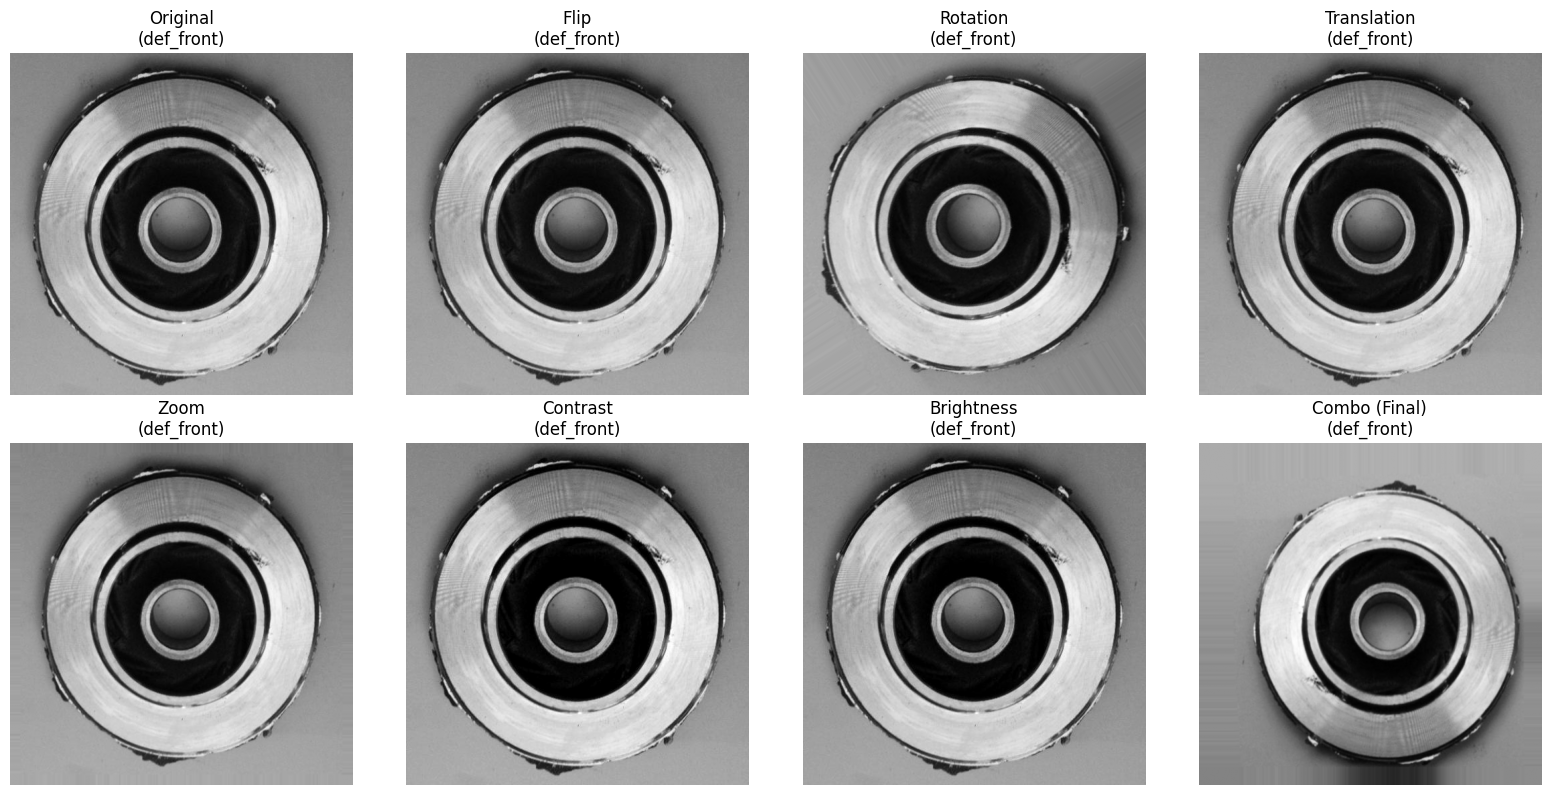

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers

# Aplicando o augmentation ao dataset de treino
# O parâmetro num_parallel_calls=AUTOTUNE ajuda na performance
dados_treino_aug = dados_treino.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

print("Data augmentation aplicado ao dataset de treino!")
print("Visualizando as transformações...\n")

# Pegando uma única imagem para demonstração
for imagens, labels in dados_treino.take(1):
    imagem_base = tf.expand_dims(imagens[0], 0)
    label_base = nomes_classes[labels[0]]

# Lista de transformações individuais baseadas no que foi definido anteriormente
transformacoes = [
    ("Original", lambda x, training=False: x),
    ("Flip", layers.RandomFlip("horizontal_and_vertical")),
    ("Rotation", layers.RandomRotation(0.2, fill_mode='nearest')),
    ("Translation", layers.RandomTranslation(0.08, 0.08, fill_mode='nearest')),
    ("Zoom", layers.RandomZoom(0.2, fill_mode='nearest')),
    ("Contrast", layers.RandomContrast(0.2)),
    ("Brightness", layers.RandomBrightness(0.2)),
    ("Combo (Final)", data_augmentation)
]

plt.figure(figsize=(16, 8))

for i, (nome, camada) in enumerate(transformacoes):
    # Aplicamos a transformação (training=True é importante para camadas Keras)
    img_result = camada(imagem_base, training=True)

    ax = plt.subplot(2, 4, i + 1)
    plt.imshow(img_result[0].numpy().astype("uint8").squeeze(), cmap='gray')
    plt.title(f"{nome}\n({label_base})")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 5. Arquitetura da Rede Neural Convolucional (CNN) e Treinamento

Construímos um modelo convolucional sequencial customizado com a seguinte estrutura:
- **Blocos Convolucionais (`Conv2D` + `BatchNormalization` + `MaxPooling2D`):** Extração hierárquica de características visuais.
- **Regularização L2 & Dropout (0.5):** Prevenção de memorização excessiva nos dados de treino.
- **Callbacks Estratégicos:** `ReduceLROnPlateau` para ajuste dinâmico da taxa de aprendizado e `EarlyStopping` para restaurar automaticamente os melhores pesos encontrados.

In [ ]:
# ======================================================
# 6. CRIANDO A ARQUITETURA CNN E TREINANDO O MODELO
# ======================================================

import tensorflow as tf
from tensorflow.keras import regularizers

# Criando um modelo Sequential CNN
# O modelo Sequential é uma pilha linear de camadas.

modelo_cnn_pecas = tf.keras.Sequential([

    # Camada de Entrada: Define o formato da imagem (512x512 pixels, 1 canal de luminosidade)
    tf.keras.layers.Input(shape=(512, 512, 1)),

    # Redimensionamento interno para 300x300
    layers.Resizing(300, 300),

    # Normalização: Redimensiona os valores dos pixels de [0, 255] para [0, 1]
    # Isso ajuda na convergência e velocidade do treinamento.
    tf.keras.layers.Rescaling(1./255),

    # Blocos Convolucionais:
    # Cada bloco extrai características da imagem (bordas, texturas, formas).

    # Bloco 1: 16 filtros
    tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    tf.keras.layers.BatchNormalization(), # Normaliza a ativação para estabilizar o treino
    tf.keras.layers.MaxPooling2D(),       # Reduz a dimensão espacial pela metade

    # Bloco 2: 32 filtros
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    # Bloco 3: 64 filtros (captura características mais complexas)
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    # Cabeçalho Classificador (Camadas Densas):

    # Converte os mapas de características 2D em um vetor 1D
    tf.keras.layers.Flatten(),

    # Camada densa com 200 neurônios para processar os recursos extraídos
    tf.keras.layers.Dense(200, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),

    # Dropout: Desativa aleatoriamente 50% dos neurônios para evitar overfitting
    tf.keras.layers.Dropout(0.5),

    # Camada de Saída: 1 neurônio com Sigmoid para classificação binária (OK ou Defeito)
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# Configurando Otimizador Adam com Gradient Clipping
#otimizador = tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0)

modelo_cnn_pecas.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Callbacks para estabilização
# O ReduceLROnPlateau reduz o learning_rate se o val_loss não melhorar após 'patience' épocas.
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

print("Modelo Sequencial pronto!\n")

# Exibindo a arquitetura do modelo
modelo_cnn_pecas.summary()

Modelo Sequencial pronto!



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 300, 300, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 300, 300, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 300, 300, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 300, 300, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 150, 150, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 87616)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 200)            │    17,523,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,547,345 (66.94 MB)

 Trainable params: 17,547,121 (66.94 MB)

 Non-trainable params: 224 (896.00 B)

In [ ]:
# Treinando o modelo

print("="*40)
print("-> 7. Treinando o Modelo CNN:")
print("="*40)
print()

freio_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    #min_delta=0.001
)

historico = modelo_cnn_pecas.fit(
    dados_treino_aug,
    validation_data=dados_val,
    epochs=40,
    callbacks=[freio_stopping],
    verbose=2
)

-> 7. Treinando o Modelo CNN:

Epoch 1/40
29/29 - 43s - 1s/step - accuracy: 0.6055 - loss: 6.9691 - val_accuracy: 0.4385 - val_loss: 11.0499
Epoch 2/40
29/29 - 62s - 2s/step - accuracy: 0.6121 - loss: 0.7651 - val_accuracy: 0.4385 - val_loss: 24.7454
Epoch 3/40
29/29 - 21s - 718ms/step - accuracy: 0.6209 - loss: 0.7183 - val_accuracy: 0.4385 - val_loss: 33.7217
Epoch 4/40
29/29 - 22s - 761ms/step - accuracy: 0.6198 - loss: 0.7123 - val_accuracy: 0.4385 - val_loss: 35.6427
Epoch 5/40
29/29 - 21s - 719ms/step - accuracy: 0.6198 - loss: 0.7678 - val_accuracy: 0.4385 - val_loss: 32.6648
Epoch 6/40
29/29 - 22s - 754ms/step - accuracy: 0.6209 - loss: 0.7406 - val_accuracy: 0.4385 - val_loss: 25.3763
Epoch 7/40
29/29 - 22s - 759ms/step - accuracy: 0.6176 - loss: 0.7054 - val_accuracy: 0.4385 - val_loss: 20.7024
Epoch 8/40
29/29 - 21s - 712ms/step - accuracy: 0.6176 - loss: 0.7033 - val_accuracy: 0.4385 - val_loss: 14.1024
Epoch 9/40
29/29 - 22s - 758ms/step - accuracy: 0.6176 - loss: 0.6923 -

# 6. Auditoria do Treinamento e Curvas de Aprendizado

Exibimos os gráficos da evolução da **Acurácia** e do erro (**Loss**) ao longo das épocas. O gráfico de erro utiliza escala logarítmica para facilitar a identificação de picos de variação e diagnosticar comportamento de *overfitting* ou instabilidade nos gradientes.

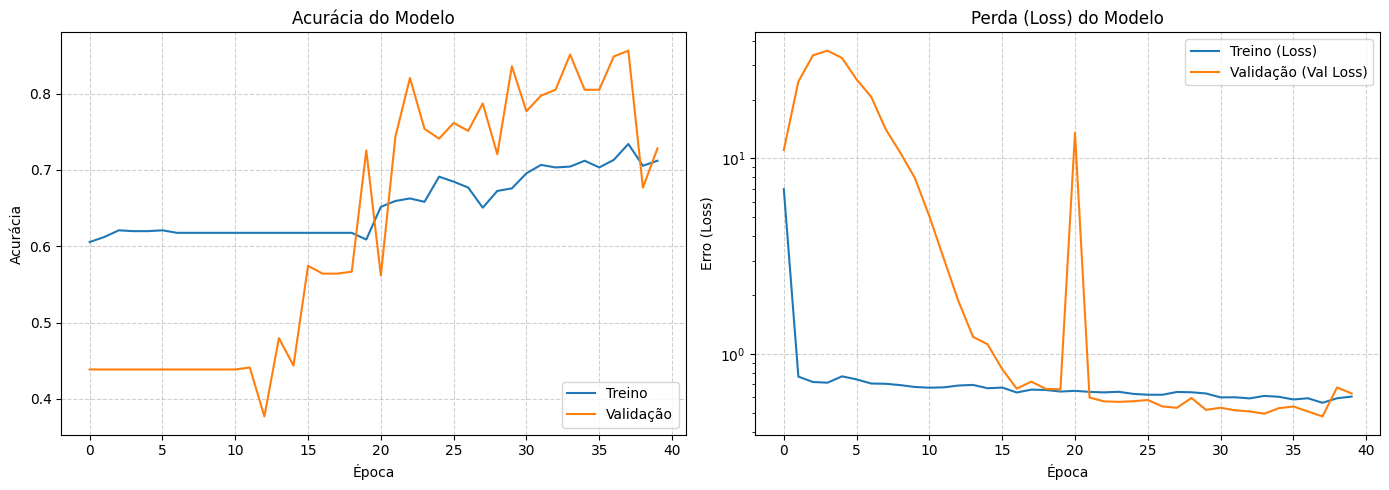

In [ ]:
import matplotlib.pyplot as plt

# Criando a figura para os dois gráficos
plt.figure(figsize=(14, 5))

# 1. Gráfico de Acurácia
plt.subplot(1, 2, 1)
plt.plot(historico.history['accuracy'], label='Treino')
plt.plot(historico.history['val_accuracy'], label='Validação')
plt.title('Acurácia do Modelo')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# 2. Gráfico de Perda (Loss)
plt.subplot(1, 2, 2)
plt.plot(historico.history['loss'], label='Treino (Loss)')
plt.plot(historico.history['val_loss'], label='Validação (Val Loss)')
plt.title('Perda (Loss) do Modelo')
plt.xlabel('Época')
plt.ylabel('Erro (Loss)')
plt.yscale('log') # Escala logarítmica para visualizar melhor os picos
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Vendo o resultado do gráfico, podemos observar que:

1. **Evolução da Acurácia:**
   * O gráfico de acurácia demonstra a trajetória de aprendizado do modelo ao longo das épocas. O alinhamento próximo entre as curvas de **Treino** e **Validação** indica um aprendizado consistente sem ocorrência severa de *overfitting* (onde o treino apresentaria desempenho perfeito e a validação estagnaria).

2. **Gráfico de Erro (Loss em Escala Logarítmica):**
   * A adoção da escala logarítmica no eixo $Y$ permite visualizar melhor a magnitude e a estabilidade das variações da função de perda.
   * A oscilação moderada na curva de `val_loss` reflete o impacto das transformações de *Data Augmentation* e a sensibilidade do modelo a peças com iluminação e ângulos variados.
   * O mecanismo de `EarlyStopping` atuou redefinindo os pesos do modelo para a época de melhor desempenho no conjunto de validação.

## 6.1 Avaliação no Conjunto de Teste Cego e Auditoria de Erros

Finalizamos com a validação do modelo em dados nunca vistos durante o treinamento:
- **Métricas Globais:** Cálculo de Acurácia, Precisão, Recall e F1-Score via `classification_report`.
- **Matriz de Confusão:** Mapeamento visual de falsos positivos e falsos negativos.
- **Auditoria Visual de Erros:** Exibição das amostras classificadas incorretamente junto ao grau de confiança, permitindo identificar os casos limites (*edge cases*) da inspeção.

Avaliação no conjunto de Teste Cego:
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8535 - loss: 0.4919

Test Accuracy: 85.35%


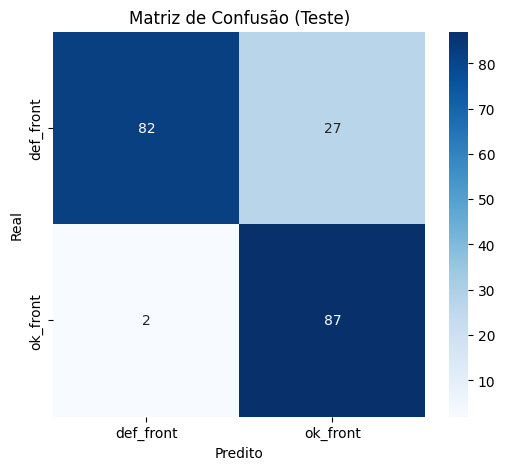


Relatório de Classificação:
              precision    recall  f1-score   support

   def_front       0.98      0.75      0.85       109
    ok_front       0.76      0.98      0.86        89

    accuracy                           0.85       198
   macro avg       0.87      0.86      0.85       198
weighted avg       0.88      0.85      0.85       198



In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Avaliação no conjunto de teste
print("Avaliação no conjunto de Teste Cego:")
loss_teste, acc_teste = modelo_cnn_pecas.evaluate(dados_teste)
print(f"\nTest Accuracy: {acc_teste*100:.2f}%")

# 2. Obtendo predições e labels reais
y_true = []
y_pred = []

for x, y in dados_teste:
    preds = modelo_cnn_pecas.predict(x, verbose=0)
    y_true.extend(y.numpy())
    y_pred.extend((preds > 0.5).astype(int).flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 3. Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=nomes_classes, yticklabels=nomes_classes)
plt.title('Matriz de Confusão (Teste)')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.show()

# 4. Relatório de Classificação
print("\nRelatório de Classificação:")
print(classification_report(y_true, y_pred, target_names=nomes_classes))

### **Relatório e Análise dos Erros**

Podemos fazer algumas conclusões a partir do resultado da Matriz de Confusão, e do Teste de Acurácia:

1. **Métricas de Desempenho Global:**
   * **Acurácia no Teste Cego:** **85.35%** (Perda/Loss: `0.4919`), obtida em um conjunto isolado de **198 amostras** (109 defeituosas e 89 normais).
   * **Detalhamento da Classe `def_front` (Com Defeito):**
     * **Precisão:** **0.98 (98%)** — Quando o modelo classifica uma peça como defeituosa, ele está correto na grande maioria das vezes (falsos alarmes extremamente baixos).
     * **Recall (Revocação):** **0.75 (75%)** — O modelo identificou corretamente 75% das peças verdadeiramente defeituosas, enquanto cerca de 25% acabaram sendo classificadas erroneamente como OK (Falsos Negativos).
   * **Detalhamento da Classe `ok_front` (Sem Defeito / Perfeita):**
     * **Precisão:** **0.76 (76%)**
     * **Recall:** **0.98 (98%)** — Alta capacidade de aprovar peças perfeitas sem rejeitá-las desnecessariamente.

2. **Análise da Matriz de Confusão:**
   * A matriz confirma que o principal ponto de atenção no ambiente industrial é o número de **Falsos Negativos** (peças com defeito que passaram como OK). Em um cenário de controle de qualidade rigoroso, é prioritário ajustar o limiar de decisão (*decision threshold*) para maximizar o *Recall* da classe de defeitos.

## 6.2 Amostra de imagens com predições erradas

Vamos pegar algumas imagens com predições erradas, assim como a porcentagem de confiança do modelo para predição (quanto o modelo acha que fez a predição correta), para ver quais as caracteristicas das imagens o modelo não conseguiu captar ou generalizar.

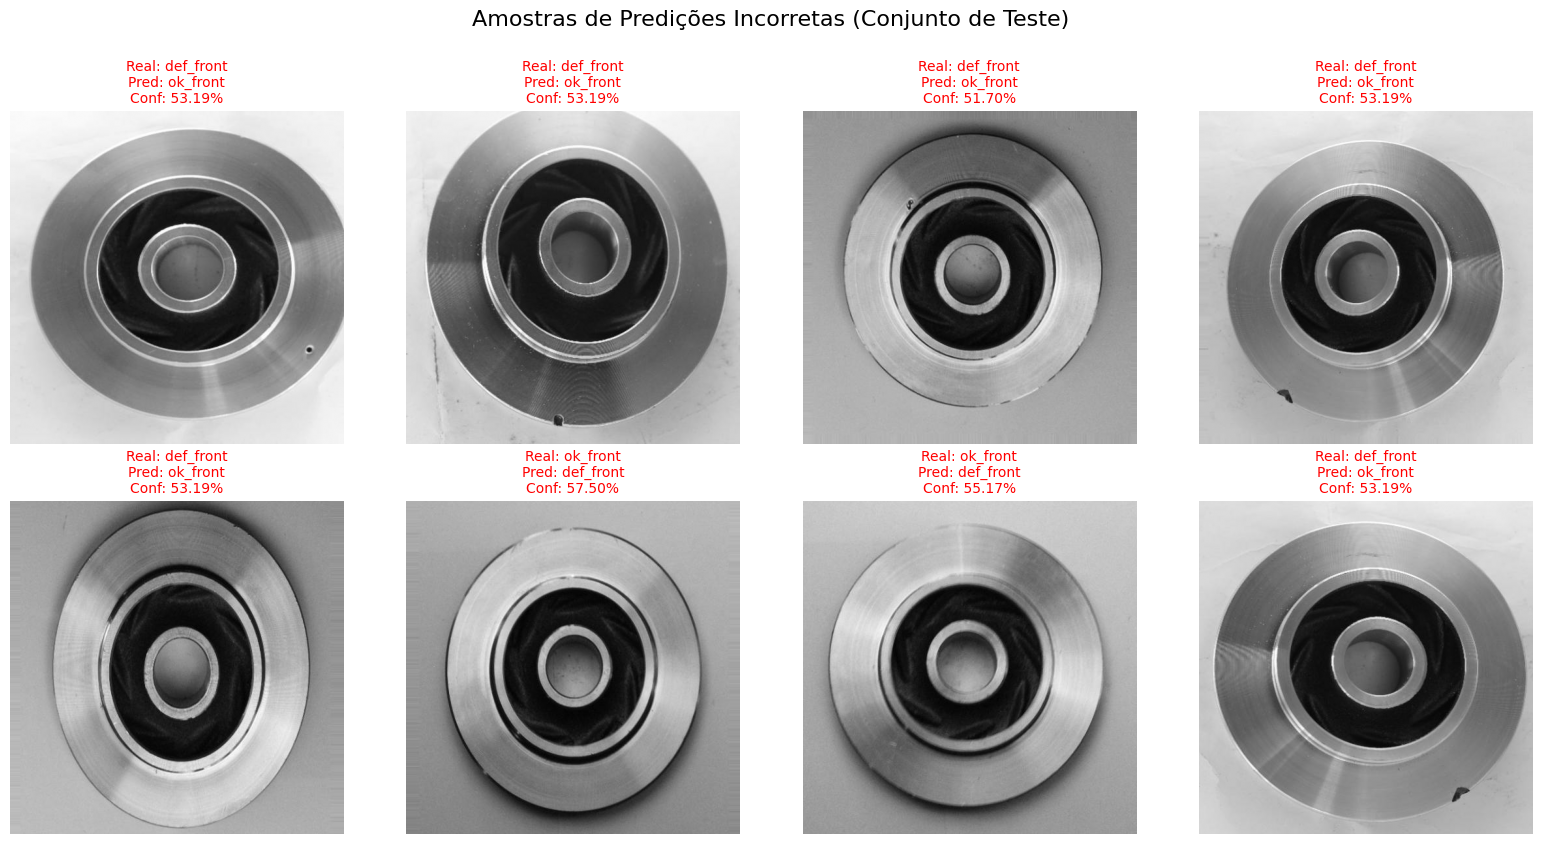

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

def visualizar_erros(dataset, modelo, nomes_classes, num_imagens=8):
    imagens_erro = []
    labels_reais = []
    labels_preds = []
    confiancas = []

    # Coletando predições incorretas
    for x, y in dataset:
        preds = modelo.predict(x, verbose=0)
        pred_classes = (preds > 0.5).astype(int).flatten()
        y_true = y.numpy().astype(int)

        # Encontra índices onde a predição foi errada
        indices_erro = np.where(pred_classes != y_true)[0]

        for idx in indices_erro:
            if len(imagens_erro) < num_imagens:
                imagens_erro.append(x[idx])
                labels_reais.append(y_true[idx])
                labels_preds.append(pred_classes[idx])
                # Calcula a confiança: se previu 1, a confiança é a própria pred, se 0, é (1 - pred)
                prob = preds[idx][0]
                conf = prob if pred_classes[idx] == 1 else 1 - prob
                confiancas.append(conf)
            else:
                break
        if len(imagens_erro) >= num_imagens: break

    # Plotagem
    plt.figure(figsize=(16, 8))
    for i in range(len(imagens_erro)):
        ax = plt.subplot(2, 4, i + 1)
        # A imagem está em escala de cinza (batch, h, w, 1), removemos a dimensão do canal
        plt.imshow(imagens_erro[i].numpy().astype("uint8").squeeze(), cmap='gray')

        cor = 'red'
        titulo = f"Real: {nomes_classes[labels_reais[i]]}\nPred: {nomes_classes[labels_preds[i]]}\nConf: {confiancas[i]*100:.2f}%"

        plt.title(titulo, color=cor, fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.suptitle("Amostras de Predições Incorretas (Conjunto de Teste)", fontsize=16, y=1.05)
    plt.show()

# Executa a visualização
visualizar_erros(dados_teste, modelo_cnn_pecas, nomes_classes)

### **Auditoria Visual das Predições Incorretas**

Comparando as imagens de peças com defeitos com as sem defeitos, junto com a porcentagem de confiança da predição feita pelo modelo, vemos que:

   * A visualização dos casos de erro revela que os equívocos ocorrem predominantemente em peças com **defeitos muito sutis** (microtrincas ou pequenas imperfeições nas bordas) ou sob **condições extremas de reflexo/iluminação**.
   * Em algumas amostras, o nível de confiança do modelo nos erros foi elevado, sinalizando a necessidade de futuras melhorias, tais como:
     * Treinamento com resolução maior das imagens;
     * Ajuste fino no *Data Augmentation*;
     * Aplicação de *Transfer Learning* (ex.: MobileNetV2 ou ResNet) para extração de características mais complexas.